Directorio: /home/coders/Escritorio/emausoft-analytics
Shape: (2823, 25)
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       

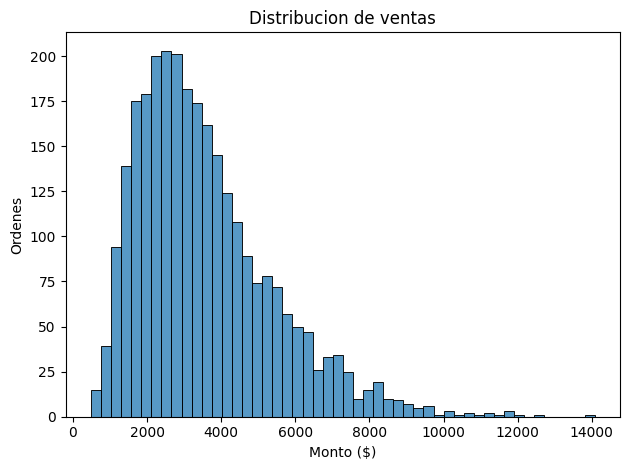

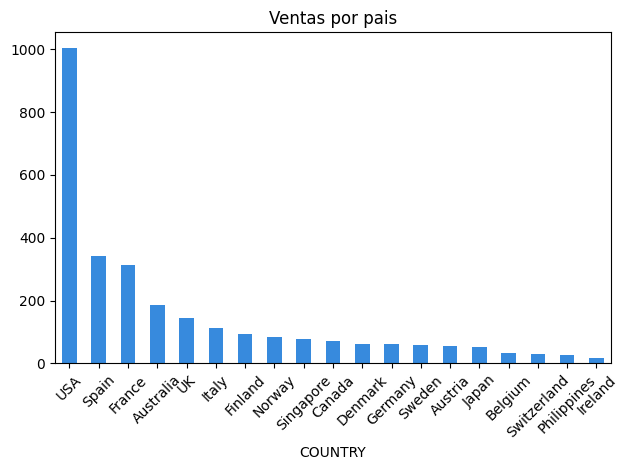

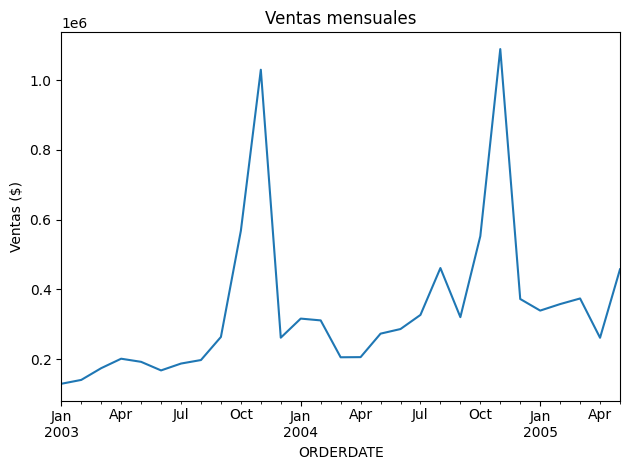

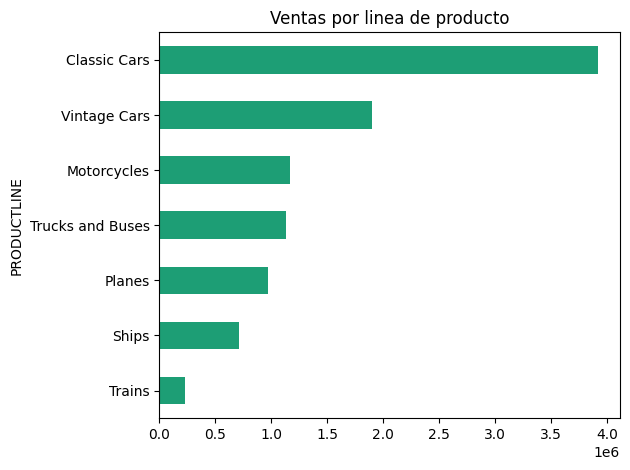

EDA completado


In [1]:
import os, sys, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path('/home/coders/Escritorio/emausoft-analytics')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print(f'Directorio: {os.getcwd()}')

# Carga de datos
df = pd.read_csv(ROOT / 'data/raw/sales_data_sample.csv', encoding='latin-1')
print(f'Shape: {df.shape}')
print(df.dtypes)
df.info()

# Limpieza basica

print('\nNulos:')
print(df.isnull().sum().sort_values(ascending=False))
print(f'Duplicados: {df.duplicated().sum()}')

# Fechas

df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'], format='mixed')
print(f'Desde: {df["ORDERDATE"].min().date()}')
print(f'Hasta: {df["ORDERDATE"].max().date()}')

# Estadisticas descriptivas

print(df[['SALES','QUANTITYORDERED','PRICEEACH','MSRP']].describe())

#   Distribucion de ventas

sns.histplot(df['SALES'], bins=50)
plt.title('Distribucion de ventas')
plt.xlabel('Monto ($)')
plt.ylabel('Ordenes')
plt.tight_layout()
plt.show()

# Ventas por pais

df['COUNTRY'].value_counts().plot(kind='bar', color='#378ADD')
plt.title('Ventas por pais')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ventas mensuales

df.groupby(df['ORDERDATE'].dt.to_period('M'))['SALES'].sum().plot()
plt.title('Ventas mensuales')
plt.ylabel('Ventas ($)')
plt.tight_layout()
plt.show()

# Ventas por linea de producto

df.groupby('PRODUCTLINE')['SALES'].sum().sort_values().plot(kind='barh', color='#1D9E75')
plt.title('Ventas por linea de producto')
plt.tight_layout()
plt.show()

print('EDA completado')